# AI-Gated Markowitz Portfolio - Year 2025 Analysis with Visualizations
This notebook includes:
1. Portfolio Value Over Time
2. Asset Allocation Stacked Area Chart
3. Bull Probability vs Portfolio Value
4. Cash Position Timeline

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Load Multi-Asset Data
file_path = 'real_crypto_data.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
print("Loaded Assets:", df.columns.tolist())

def get_market_features(df):
    returns = df.pct_change().fillna(0)
    volatility = returns.rolling(window=20).std().fillna(0)
    sma50 = df.rolling(window=50).mean()
    momentum = (df / sma50 - 1).fillna(0)
    return returns, volatility, momentum

returns_df, vol_df, mom_df = get_market_features(df)
assets = df.columns.tolist()
n_assets = len(assets)

# Define Training Range (2023 and 2024)
train_mask = (df.index.year == 2023) | (df.index.year == 2024)
train_df_slice = df[train_mask]
train_returns_slice = returns_df[train_mask]

# Define Test Range (2025 Only)
test_mask = (df.index.year == 2025)
test_df_slice = df[test_mask]
test_returns_slice = returns_df[test_mask]

print(f"Total Data Points: {len(df)}")
print(f"Training Data (2023-2024): {len(train_df_slice)} days")
print(f"Testing Data (2025): {len(test_df_slice)} days")

Loaded Assets: ['BCH', 'BTC', 'ETH', 'LTC', 'XRP']
Total Data Points: 1096
Training Data (2023-2024): 731 days
Testing Data (2025): 365 days


In [3]:
# Train AI Gatekeeper (Bull/Bear Classifier)
print('Training AI Gatekeeper (Bull/Bear Classifier)...')
market_ret = returns_df.mean(axis=1)
feat = pd.DataFrame(index=returns_df.index)
feat['Vol_20'] = market_ret.rolling(20).std()
feat['Mom_20'] = market_ret.rolling(20).mean()
feat['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat = feat.dropna()

X_rf = feat[['Vol_20', 'Mom_20']]
y_rf = feat['Target']

# Train on 2023-2024 data only
train_rf_mask = (feat.index.year == 2023) | (feat.index.year == 2024)
X_train_rf = X_rf[train_rf_mask]
y_train_rf = y_rf[train_rf_mask]

clf = RandomForestClassifier(n_estimators=100, min_samples_split=10, random_state=42)
clf.fit(X_train_rf, y_train_rf)

# Predict on ALL data
rf_probs_all = clf.predict_proba(X_rf)[:, 1]
rf_probs_series = pd.Series(rf_probs_all, index=X_rf.index)
print(f'AI Gatekeeper Trained. Train Acc: {accuracy_score(y_train_rf, clf.predict(X_train_rf)):.2f}')

Training AI Gatekeeper (Bull/Bear Classifier)...
AI Gatekeeper Trained. Train Acc: 0.88


In [4]:
# Markowitz Optimization Function
def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0: 
        return np.array([])
    
    def neg_sharpe(weights):
        portfolio_return = np.sum(returns_window.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(portfolio_return / portfolio_vol) if portfolio_vol > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return res.x
    except:
        return np.array(init_guess)

print('Markowitz optimization function defined')

Markowitz optimization function defined


In [5]:
# Run AI-Gated Markowitz Strategy on 2025 Test Data
print(f"\n{'='*10} Running AI-Gated Markowitz on Year 2025 {'='*10}")

# Initialize
initial_capital = 100.0
lookback = 50
portfolio_history = []
current_value = initial_capital

# Iterate through 2025 test data
for step in range(len(test_df_slice) - 1):
    current_date = test_df_slice.index[step]
    current_prices = test_df_slice.iloc[step].values
    next_returns = test_returns_slice.iloc[step + 1].values
    
    # Calculate Markowitz weights
    glob_idx = returns_df.index.get_loc(current_date)
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    # Apply AI Gating
    if current_date in rf_probs_series.index:
        bull_prob = rf_probs_series.loc[current_date]
        if bull_prob > 0.52:
            ai_weights = mw_weights
        elif bull_prob < 0.48:
            ai_weights = np.zeros(n_assets)
        else:
            ai_weights = 0.5 * mw_weights
    else:
        ai_weights = 0.5 * mw_weights
    
    # Calculate allocations
    dollar_allocation = current_value * ai_weights
    units = dollar_allocation / current_prices
    total_invested = np.sum(ai_weights)
    cash_percentage = 1.0 - total_invested
    cash_usd = current_value * cash_percentage
    
    # Calculate return and update value
    portfolio_return = np.sum(ai_weights * next_returns)
    current_value = current_value * (1 + portfolio_return)
    
    # Store data
    portfolio_data = {
        'Date': current_date,
        'Bull_Probability': rf_probs_series.loc[current_date] * 100 if current_date in rf_probs_series.index else np.nan
    }
    
    for i, asset in enumerate(assets):
        portfolio_data[f'{asset}_units'] = units[i]
        portfolio_data[f'{asset}_weight_%'] = ai_weights[i] * 100
    
    portfolio_data['Cash_USD'] = cash_usd
    portfolio_data['Cash_%'] = cash_percentage * 100
    portfolio_data['Portfolio_Value_USD'] = current_value
    portfolio_history.append(portfolio_data)

portfolio_df = pd.DataFrame(portfolio_history)

print(f"\nFinal Portfolio Value: ${current_value:.2f}")
print(f"Total Return: {((current_value - initial_capital) / initial_capital * 100):.2f}%")
print(f"Portfolio data collected for {len(portfolio_df)} days")


========== Running AI-Gated Markowitz on Year 2025 ==========

Final Portfolio Value: $190.93
Total Return: 90.93%
Portfolio data collected for 364 days


## 📊 Visualizations

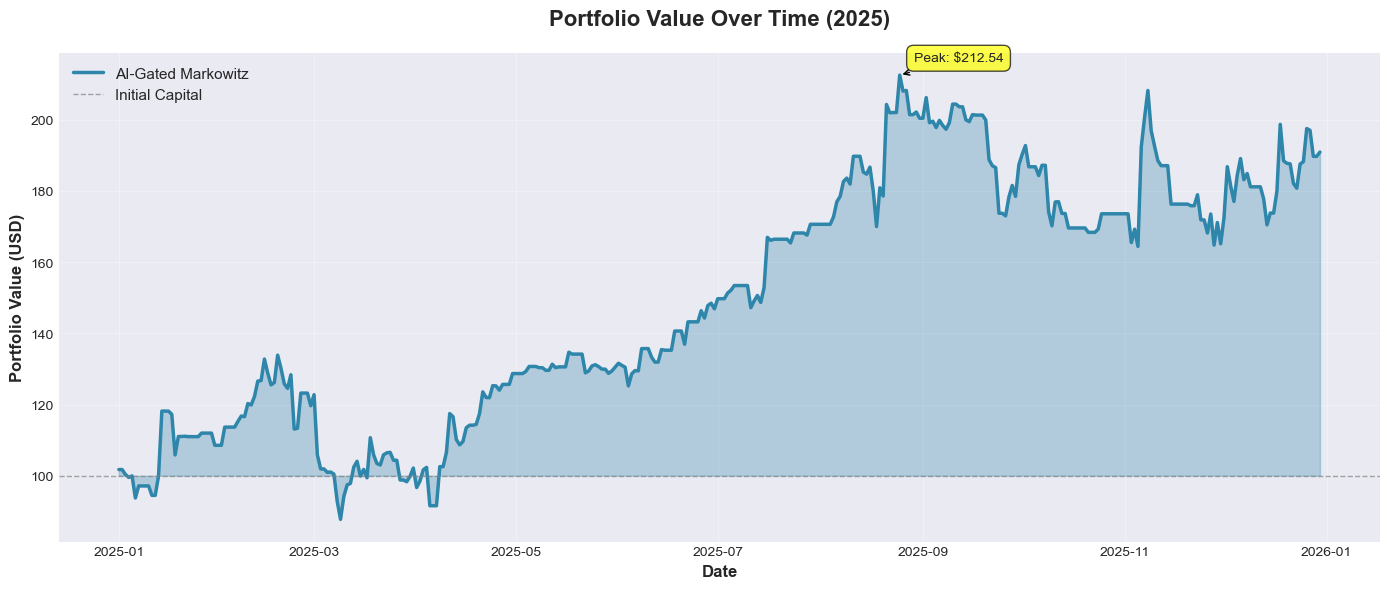

✅ Chart 1: Portfolio Value Over Time - Saved!


In [6]:
# Chart 1: Portfolio Value Over Time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(portfolio_df['Date'], portfolio_df['Portfolio_Value_USD'], 
        linewidth=2.5, color='#2E86AB', label='AI-Gated Markowitz')
ax.axhline(y=initial_capital, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Initial Capital')

# Fill area under curve
ax.fill_between(portfolio_df['Date'], initial_capital, portfolio_df['Portfolio_Value_USD'], 
                alpha=0.3, color='#2E86AB')

ax.set_title('Portfolio Value Over Time (2025)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Portfolio Value (USD)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotations
max_val = portfolio_df['Portfolio_Value_USD'].max()
max_date = portfolio_df.loc[portfolio_df['Portfolio_Value_USD'].idxmax(), 'Date']
ax.annotate(f'Peak: ${max_val:.2f}', 
            xy=(max_date, max_val), 
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.savefig('chart1_portfolio_value.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart 1: Portfolio Value Over Time - Saved!")

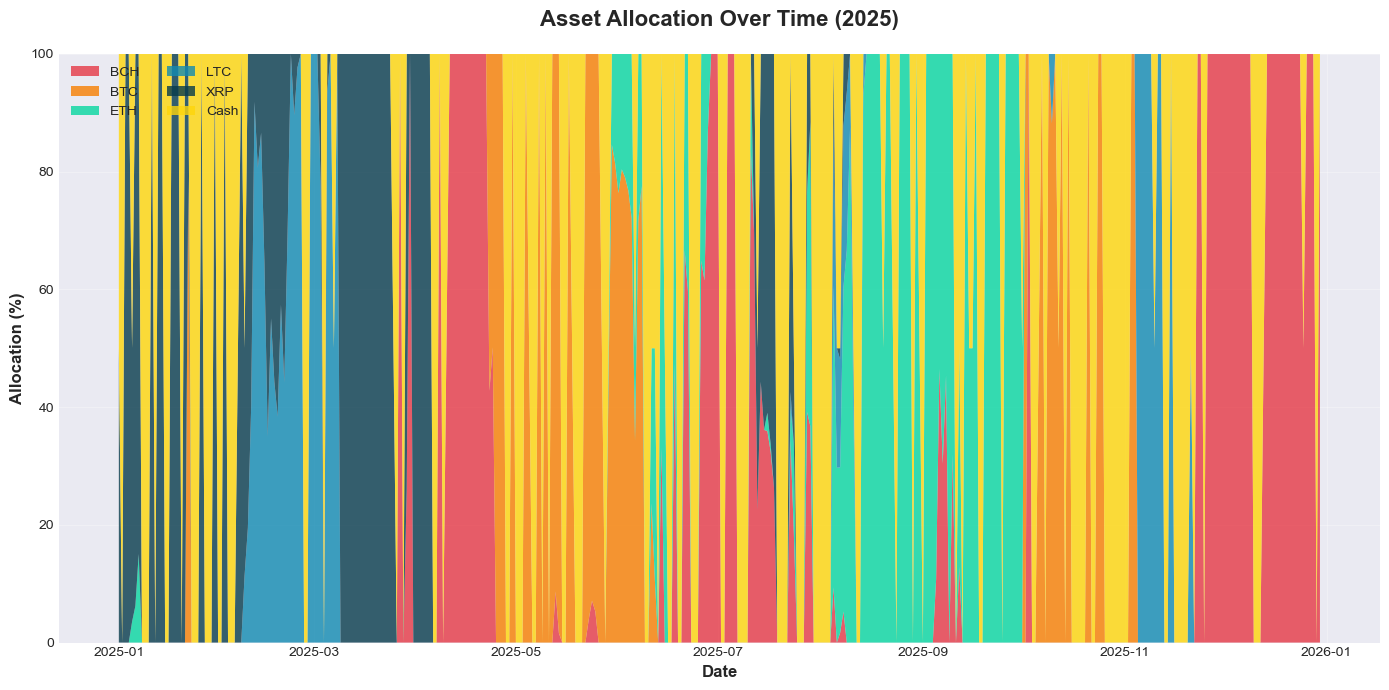

✅ Chart 2: Asset Allocation Stacked Area - Saved!


In [7]:
# Chart 2: Asset Allocation Stacked Area Chart
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data for stacked area
allocation_data = portfolio_df[['Date'] + [f'{asset}_weight_%' for asset in assets] + ['Cash_%']].copy()
allocation_data.set_index('Date', inplace=True)

# Create stacked area plot
colors = ['#E63946', '#F77F00', '#06D6A0', '#118AB2', '#073B4C', '#FFD60A']
ax.stackplot(allocation_data.index, 
             *[allocation_data[f'{asset}_weight_%'] for asset in assets],
             allocation_data['Cash_%'],
             labels=assets + ['Cash'],
             colors=colors,
             alpha=0.8)

ax.set_title('Asset Allocation Over Time (2025)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Allocation (%)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, ncol=2)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_asset_allocation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart 2: Asset Allocation Stacked Area - Saved!")

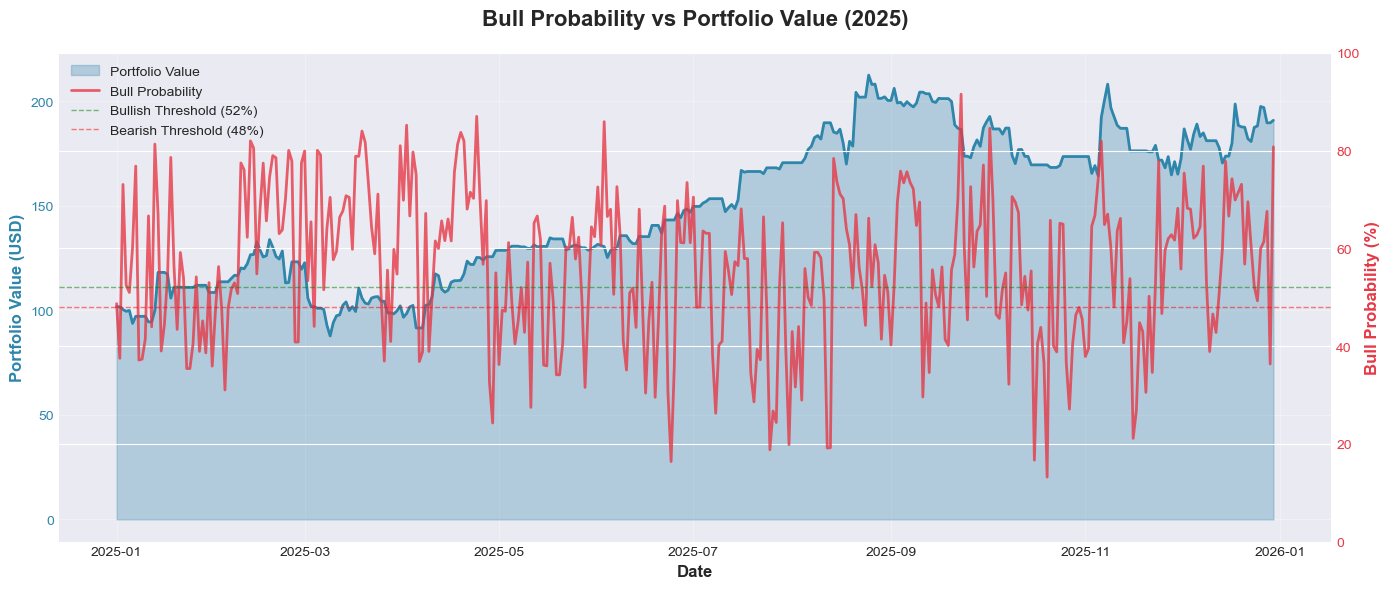

✅ Chart 3: Bull Probability vs Portfolio Value - Saved!


In [8]:
# Chart 3: Bull Probability vs Portfolio Value (Dual Axis)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Portfolio Value (left axis)
color = '#2E86AB'
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio Value (USD)', color=color, fontsize=12, fontweight='bold')
ax1.fill_between(portfolio_df['Date'], portfolio_df['Portfolio_Value_USD'], 
                 alpha=0.3, color=color, label='Portfolio Value')
ax1.plot(portfolio_df['Date'], portfolio_df['Portfolio_Value_USD'], 
         color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Bull Probability (right axis)
ax2 = ax1.twinx()
color = '#E63946'
ax2.set_ylabel('Bull Probability (%)', color=color, fontsize=12, fontweight='bold')
ax2.plot(portfolio_df['Date'], portfolio_df['Bull_Probability'], 
         color=color, linewidth=2, alpha=0.8, label='Bull Probability')
ax2.axhline(y=52, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Bullish Threshold (52%)')
ax2.axhline(y=48, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Bearish Threshold (48%)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 100)

# Title and legends
ax1.set_title('Bull Probability vs Portfolio Value (2025)', fontsize=16, fontweight='bold', pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('chart3_bull_prob_vs_value.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart 3: Bull Probability vs Portfolio Value - Saved!")

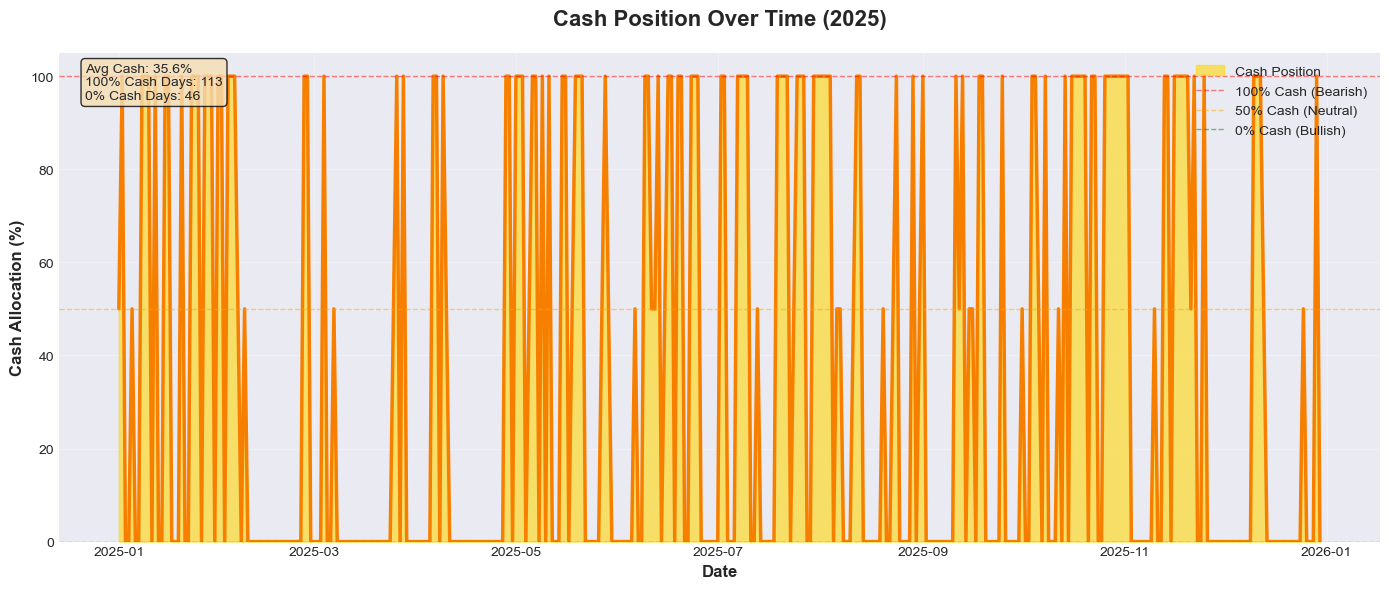

✅ Chart 4: Cash Position Timeline - Saved!


In [9]:
# Chart 4: Cash Position Timeline
fig, ax = plt.subplots(figsize=(14, 6))

# Create color map based on cash percentage
colors_map = []
for cash_pct in portfolio_df['Cash_%']:
    if cash_pct == 100:
        colors_map.append('#E63946')  # Red for 100% cash (bearish)
    elif cash_pct == 0:
        colors_map.append('#06D6A0')  # Green for 0% cash (bullish)
    else:
        colors_map.append('#F77F00')  # Orange for partial cash (neutral)

ax.fill_between(portfolio_df['Date'], portfolio_df['Cash_%'], 
                alpha=0.6, color='#FFD60A', label='Cash Position')
ax.plot(portfolio_df['Date'], portfolio_df['Cash_%'], 
        color='#F77F00', linewidth=2.5)

# Add horizontal lines for reference
ax.axhline(y=100, color='red', linestyle='--', linewidth=1, alpha=0.5, label='100% Cash (Bearish)')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='50% Cash (Neutral)')
ax.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='0% Cash (Bullish)')

ax.set_title('Cash Position Over Time (2025)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Cash Allocation (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Add statistics text box
stats_text = f"Avg Cash: {portfolio_df['Cash_%'].mean():.1f}%\n"
stats_text += f"100% Cash Days: {(portfolio_df['Cash_%'] == 100).sum()}\n"
stats_text += f"0% Cash Days: {(portfolio_df['Cash_%'] == 0).sum()}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('chart4_cash_position.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart 4: Cash Position Timeline - Saved!")

In [10]:
# Save data to Excel
output_file = 'ai_gated_markowitz_portfolio_2025_with_charts.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    portfolio_df.to_excel(writer, sheet_name='Portfolio_Data', index=False)

print(f"\n{'='*60}")
print(f"✅ Portfolio data saved to: {output_file}")
print(f"✅ All 4 charts saved as PNG files")
print(f"{'='*60}")


✅ Portfolio data saved to: ai_gated_markowitz_portfolio_2025_with_charts.xlsx
✅ All 4 charts saved as PNG files


In [11]:
# Summary Statistics
print("\n" + "="*50)
print("PORTFOLIO SUMMARY STATISTICS")
print("="*50)
print(f"\nInitial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${current_value:.2f}")
print(f"Total Return: {((current_value - initial_capital) / initial_capital * 100):.2f}%")
print(f"\nMax Portfolio Value: ${portfolio_df['Portfolio_Value_USD'].max():.2f}")
print(f"Min Portfolio Value: ${portfolio_df['Portfolio_Value_USD'].min():.2f}")
print(f"\nAverage Cash Position: {portfolio_df['Cash_%'].mean():.2f}%")
print(f"Days with 100% Cash: {(portfolio_df['Cash_%'] == 100).sum()} days")
print(f"Days with 0% Cash: {(portfolio_df['Cash_%'] == 0).sum()} days")


PORTFOLIO SUMMARY STATISTICS

Initial Capital: $100.00
Final Portfolio Value: $190.93
Total Return: 90.93%

Max Portfolio Value: $212.54
Min Portfolio Value: $87.75

Average Cash Position: 35.58%
Days with 100% Cash: 113 days
Days with 0% Cash: 46 days
